In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df=pd.read_csv("../data/cleaned/cleaned_hr_emp_data.csv")

In [5]:
df.shape

(1470, 31)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

In [7]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [13]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [15]:
df['Attrition'].value_counts(normalize=True)*100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

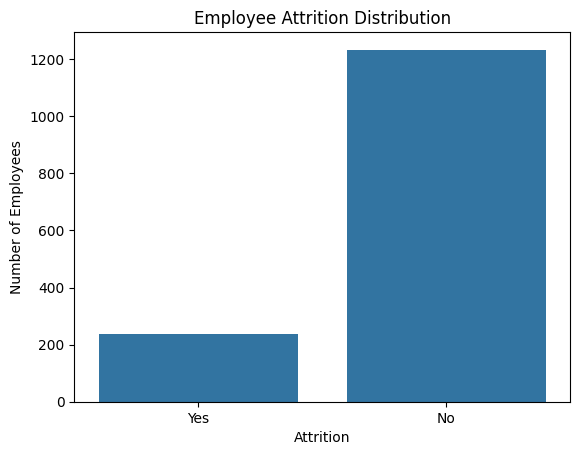

In [18]:
sns.countplot(data=df,x='Attrition')
plt.title('Employee Attrition Distribution')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')
plt.show()

In [20]:
age=[18,25,35,45,55,65]
label=['18-25','26-35','35-45','46-55','56-65']
df['AgeGroup']=pd.cut(df['Age'],bins=age,labels=label)


In [21]:
df['AgeGroup']

0       35-45
1       46-55
2       35-45
3       26-35
4       26-35
        ...  
1465    35-45
1466    35-45
1467    26-35
1468    46-55
1469    26-35
Name: AgeGroup, Length: 1470, dtype: category
Categories (5, object): ['18-25' < '26-35' < '35-45' < '46-55' < '56-65']

In [ ]:
age_attrition=df.groupby('AgeGroup',observed=True)['Attrition'].apply(lambda x:(x=='Yes').mean()*100)

In [39]:
age_attrition.sort_values(ascending=False,inplace=True)

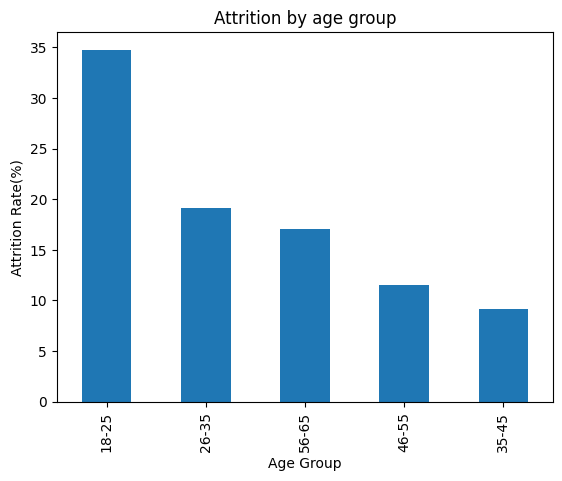

In [40]:
age_attrition.plot(kind='bar')
plt.title("Attrition by age group")
plt.xlabel('Age Group')
plt.ylabel('Attrition Rate(%)')
plt.show()

In [45]:
gender_attrition=df.groupby('Gender')['Attrition'].apply(lambda x:(x=='Yes').mean()*100)

In [46]:
gender_attrition

Gender
Female    14.795918
Male      17.006803
Name: Attrition, dtype: float64

In [53]:
marital_attrition=df.groupby('MaritalStatus')['Attrition'].apply(lambda x:(x=='Yes').mean()*100)
marital_attrition

MaritalStatus
Divorced    10.091743
Married     12.481426
Single      25.531915
Name: Attrition, dtype: float64

In [56]:
department_attrition=df.groupby('Department')['Attrition'].apply(lambda x:(x=='Yes').mean()*100)
department_attrition.sort_values(ascending=False,inplace=True)
department_attrition

Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750
Name: Attrition, dtype: float64

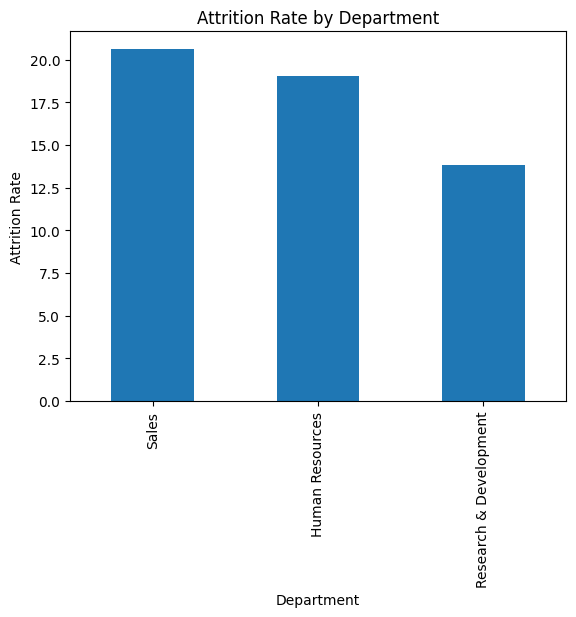

In [57]:
department_attrition.plot(kind='bar')
plt.title('Attrition Rate by Department')
plt.xlabel('Department')
plt.ylabel('Attrition Rate')
plt.show()

In [61]:
jobrole_attrition=df.groupby('JobRole')['Attrition'].apply(lambda x:(x=='Yes').mean()*100).sort_values(ascending=False)
jobrole_attrition

JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: Attrition, dtype: float64

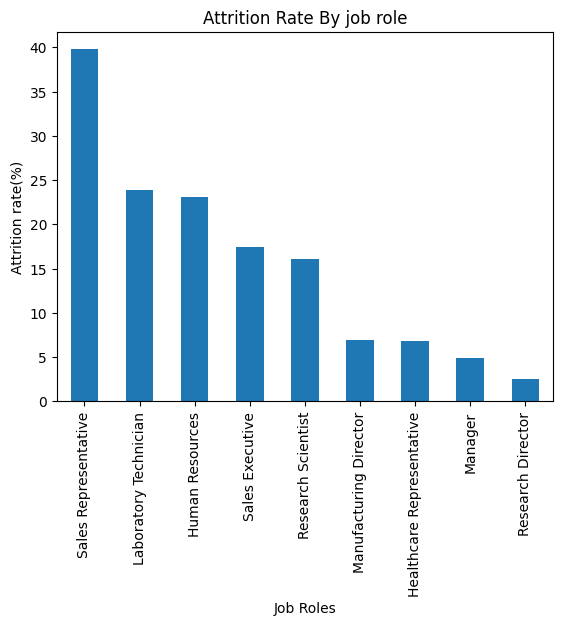

In [63]:
jobrole_attrition.plot(kind='bar')
plt.title('Attrition Rate By job role')
plt.xlabel('Job Roles')
plt.ylabel('Attrition rate(%)')
plt.show()

In [64]:
jobrole_attrition.head()

JobRole
Sales Representative     39.759036
Laboratory Technician    23.938224
Human Resources          23.076923
Sales Executive          17.484663
Research Scientist       16.095890
Name: Attrition, dtype: float64

In [65]:
df['JobLevel']

0       2
1       2
2       1
3       1
4       1
       ..
1465    2
1466    3
1467    2
1468    2
1469    2
Name: JobLevel, Length: 1470, dtype: int64

In [68]:
joblevel_attrition=df.groupby('JobLevel')['Attrition'].apply(lambda x:(x=='Yes').mean()*100).sort_values(ascending=False)
joblevel_attrition

JobLevel
1    26.335175
3    14.678899
2     9.737828
5     7.246377
4     4.716981
Name: Attrition, dtype: float64

In [69]:
overtime_attrition=df.groupby('OverTime')['Attrition'].apply(lambda x:(x=='Yes').mean()*100).sort_values(ascending=False)
overtime_attrition

OverTime
Yes    30.528846
No     10.436433
Name: Attrition, dtype: float64

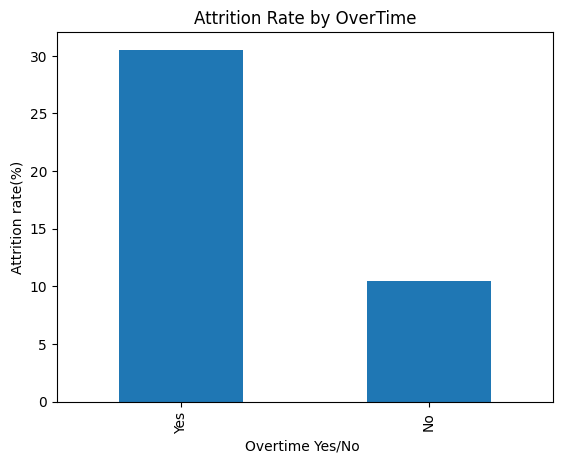

In [70]:
overtime_attrition.plot(kind='bar')
plt.title('Attrition Rate by OverTime')
plt.xlabel('Overtime Yes/No ')
plt.ylabel('Attrition rate(%)')
plt.show()

In [81]:
dept_overtime=df.groupby('Department')['OverTime'].apply(lambda x:(x=='Yes').mean()*100)
emp_dept_overtime=dept_overtime.idxmax()
emp_dept_overtime

'Sales'

In [85]:
travel_attrition=df.groupby('BusinessTravel')['Attrition'].apply(lambda x:(x=="Yes").mean()*100).sort_values(ascending=False)
travel_attrition

BusinessTravel
Travel_Frequently    24.909747
Travel_Rarely        14.956855
Non-Travel            8.000000
Name: Attrition, dtype: float64

#### Do Employees living farther from the workplace leave more ?

In [91]:
df.groupby('Attrition')['DistanceFromHome'].mean()

Attrition
No      8.915653
Yes    10.632911
Name: DistanceFromHome, dtype: float64

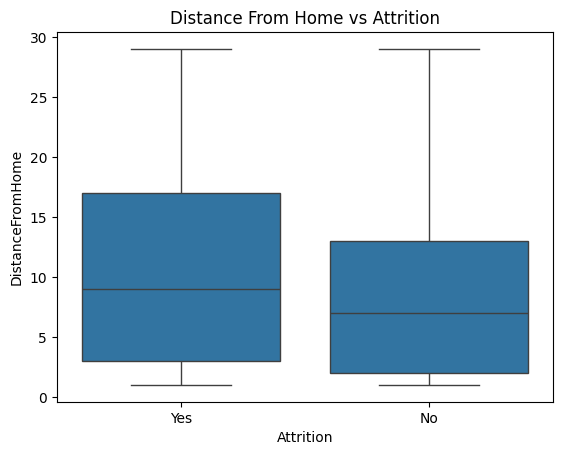

In [93]:
sns.boxplot(data=df,x='Attrition',y='DistanceFromHome')
plt.title('Distance From Home vs Attrition')
plt.show()